Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning
        ↓
Handle Missing Values
        ↓
Handle Outliers (if required)
        ↓
Exploratory Data Analysis (EDA)
        ↓
Feature Engineering (if required)
        ↓
Encoding (if categorical data)
        ↓
Define Features (X) and Target (y)
        ↓
Train-Validation-Test Split
        ↓
Feature Scaling (Normalization / Standardization)
        ↓
Convert to Tensors
        ↓
Create Dataset & DataLoader
        ↓
Design Neural Network Architecture
        ↓
Choose Loss Function
        ↓
Choose Optimizer
        ↓
Training Loop
        ↓
Validation
        ↓
Hyperparameter Tuning
        ↓
Model Evaluation
        ↓
Save Trained Model
        ↓
Inference / Prediction
        ↓
Deployment
        ↓
GitHub + README

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 


In [61]:
import random
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
data = pd.read_csv(r"C:\Users\shobh\OneDrive\Attachments\Documents\Desktop\py\credit_card_frauds.csv")

df = pd.DataFrame(data)

In [3]:
df

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339602,2020-12-31 23:57:56,Schmidt-Larkin,home,12.68,Wales,AK,64.7556,-165.6723,145,"Administrator, education",1939-11-09,a8310343c189e4a5b6316050d2d6b014,65.623593,-165.186033,0
339603,2020-12-31 23:58:04,"Pouros, Walker and Spence",kids_pets,13.02,Greenview,CA,41.5403,-122.9366,308,Call centre manager,1958-09-20,bd7071fd5c9510a5594ee196368ac80e,41.973127,-123.553032,0
339604,2020-12-31 23:59:07,Reilly and Sons,health_fitness,43.77,Luray,MO,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,39.946837,-91.333331,0
339605,2020-12-31 23:59:15,Rau-Robel,kids_pets,86.88,Burbank,WA,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,46.658340,-119.715054,0


## <span style="color:#DC2626; font-family:Georgia;">Target Variable :</span>

- **<span style="color:#16A34A;">0</span>** → **<span style="color:#2563EB;">Legitimate Transaction</span>**
- **<span style="color:#DC2626;">1</span>** → **<span style="color:#EA580C;">Fraudulent Transaction</span>**

In [4]:
#data understandings


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

In [5]:
df.isnull().sum()

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

</span>**<span style="color:#2563EB;">No null values found</span>**

In [6]:
df.duplicated().sum()

np.int64(0)

</span>**<span style="color:#2563EB;">No duplicated rows found</span>**

In [7]:
df.nunique()

trans_date_trans_time    338504
merchant                    693
category                     14
amt                       32112
city                        176
state                        13
lat                         183
long                        183
city_pop                    174
job                         163
dob                         187
trans_num                339607
merch_lat                335608
merch_long               337263
is_fraud                      2
dtype: int64

In [8]:
df.sample()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
71736,2019-06-27 17:26:32,"Hagenes, Kohler and Hoppe",food_dining,54.34,Rocky Mount,MO,38.2911,-92.7059,1847,Tax inspector,1988-10-26,4a4480bd020d14bdfedc625ed76046c1,38.946986,-92.871027,0


In [9]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [10]:
#data cleaning


df.drop(['trans_date_trans_time','dob','trans_num'],axis = 1,inplace=True)

In [11]:

df_cleaned = df.copy()

df_cleaned.to_csv(
    r"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗗𝗲𝗲𝗽 𝗟𝗲𝗮𝗿𝗻𝗶𝗻𝗴 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\𝗗𝗲𝗲𝗽 𝗟𝗲𝗮𝗿𝗻𝗶𝗻𝗴 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀 (𝗧𝗮𝗯𝘂𝗹𝗮𝗿 𝗗𝗮𝘁𝗮)\Credit Card Fraud Detection\data\credit_card_frauds_cleaned.csv",
    index=False
)

#skiping eda for you claude 


make sevral observation write it in observations markdowan cell and use various html and .md syntax to make it colourful and good and also save all graphs here 

"C:\Users\shobh\Downloads\AI and DATA SCIENCE\𝗗𝗲𝗲𝗽 𝗟𝗲𝗮𝗿𝗻𝗶𝗻𝗴 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀\𝗗𝗲𝗲𝗽 𝗟𝗲𝗮𝗿𝗻𝗶𝗻𝗴 𝗣𝗿𝗼𝗷𝗲𝗰𝘁𝘀 (𝗧𝗮𝗯𝘂𝗹𝗮𝗿 𝗗𝗮𝘁𝗮)\Credit Card Fraud Detection\images"


and write observation and all colourful in box with professionalism 

## <span style="color:#B8860B; font-family:Georgia;">📊 Exploratory Data Analysis</span>

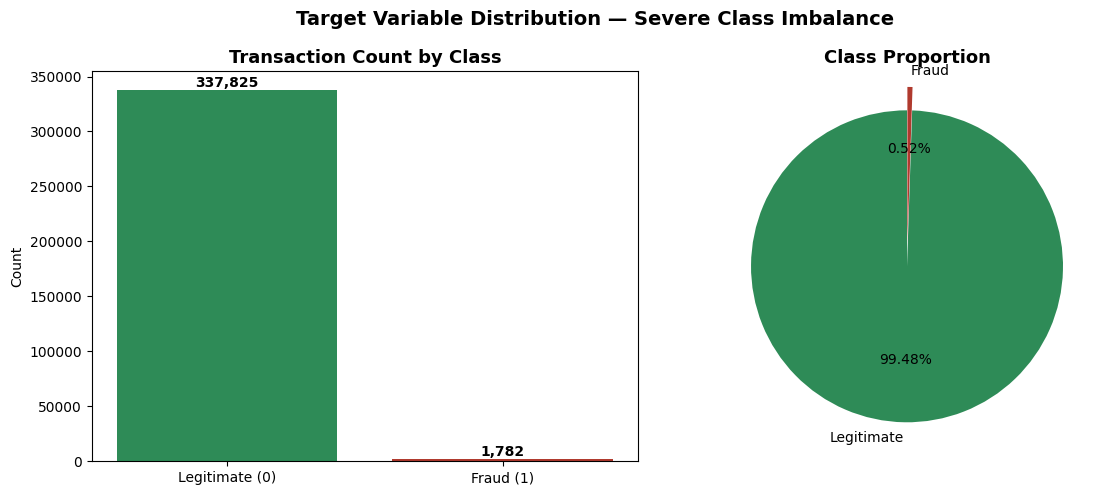

Legitimate: 337,825 (99.475%)
Fraud:      1,782 (0.525%)
Imbalance ratio: 1 fraud for every 189 legitimate transactions


In [62]:
# EDA — target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['is_fraud'].value_counts()
colors = ['#2E8B57', '#B03A2E']

axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=colors)
axes[0].set_title('Transaction Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha='center', va='bottom', fontweight='bold')

axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=colors, startangle=90, explode=(0, 0.15))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution — Severe Class Imbalance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Legitimate: {counts[0]:,} ({counts[0]/len(df)*100:.3f}%)")
print(f"Fraud:      {counts[1]:,} ({counts[1]/len(df)*100:.3f}%)")
print(f"Imbalance ratio: 1 fraud for every {counts[0]//counts[1]} legitimate transactions")

/tmp/ipykernel_877/3780794529.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_fraud', y='amt', data=df, ax=axes[1], palette=['#2E8B57', '#B03A2E'])


/tmp/ipykernel_877/3780794529.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Legitimate', 'Fraud'])


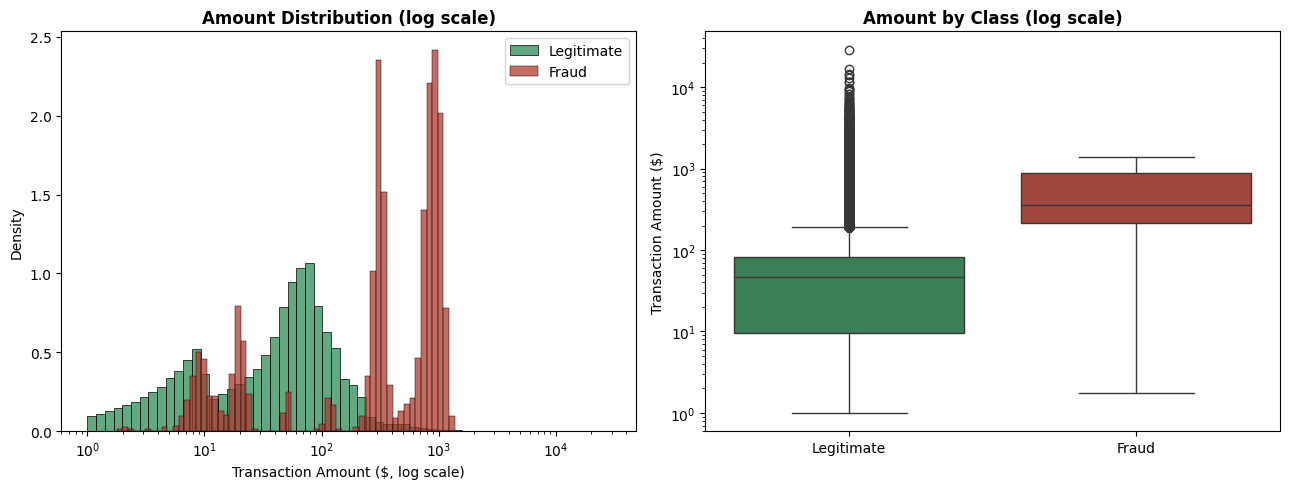

            mean  median     std       max
is_fraud                                  
0          68.22   46.25  156.25  28948.90
1         518.07  356.44  389.63   1371.81


In [63]:
# EDA — transaction amount distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df[df['is_fraud']==0]['amt'], bins=60, color='#2E8B57', label='Legitimate',
             stat='density', ax=axes[0], log_scale=True)
sns.histplot(df[df['is_fraud']==1]['amt'], bins=60, color='#B03A2E', label='Fraud',
             stat='density', ax=axes[0], log_scale=True)
axes[0].set_title('Amount Distribution (log scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transaction Amount ($, log scale)')
axes[0].legend()

sns.boxplot(x='is_fraud', y='amt', data=df, ax=axes[1], palette=['#2E8B57', '#B03A2E'])
axes[1].set_yscale('log')
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_title('Amount by Class (log scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Transaction Amount ($)')

plt.tight_layout()
plt.savefig('../images/02_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('is_fraud')['amt'].agg(['mean','median','std','max']).round(2))

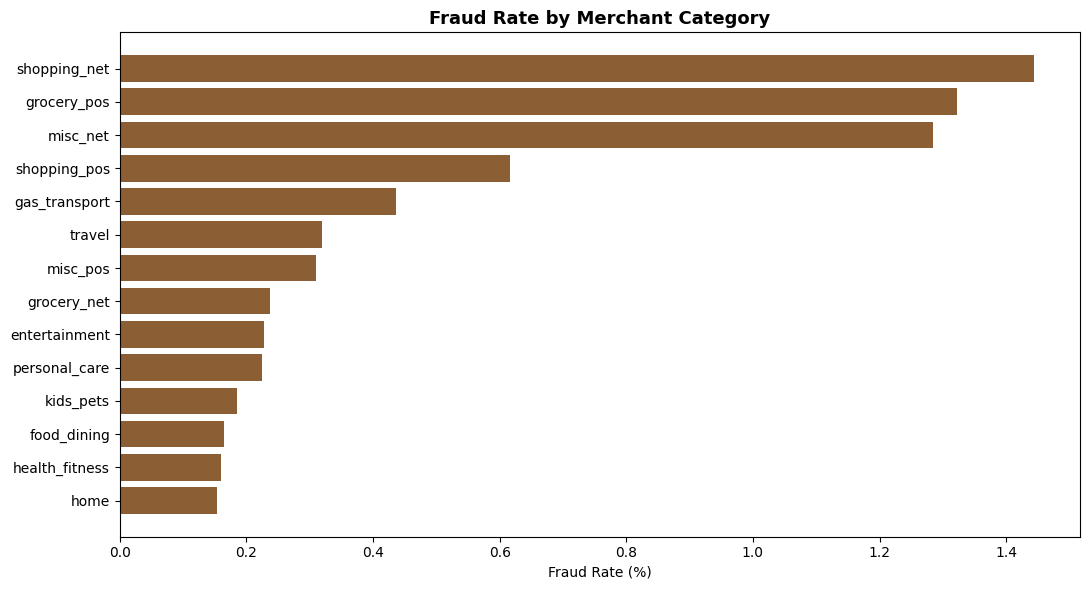

,count,sum,fraud_rate_pct
category,,,
shopping_net,26379,381,1.444
grocery_pos,32732,433,1.323
misc_net,16898,217,1.284
shopping_pos,30329,187,0.617
gas_transport,35089,153,0.436
travel,10322,33,0.320
misc_pos,20024,62,0.310
grocery_net,11355,27,0.238
entertainment,24222,55,0.227


In [64]:
# EDA — fraud rate by merchant category
cat_fraud = df.groupby('category')['is_fraud'].agg(['count','sum','mean']).sort_values('mean', ascending=False)
cat_fraud['fraud_rate_pct'] = cat_fraud['mean'] * 100

plt.figure(figsize=(11, 6))
bars = plt.barh(cat_fraud.index[::-1], cat_fraud['fraud_rate_pct'][::-1], color='#8B5E34')
plt.xlabel('Fraud Rate (%)')
plt.title('Fraud Rate by Merchant Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_category_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()

cat_fraud[['count','sum','fraud_rate_pct']].round(3)

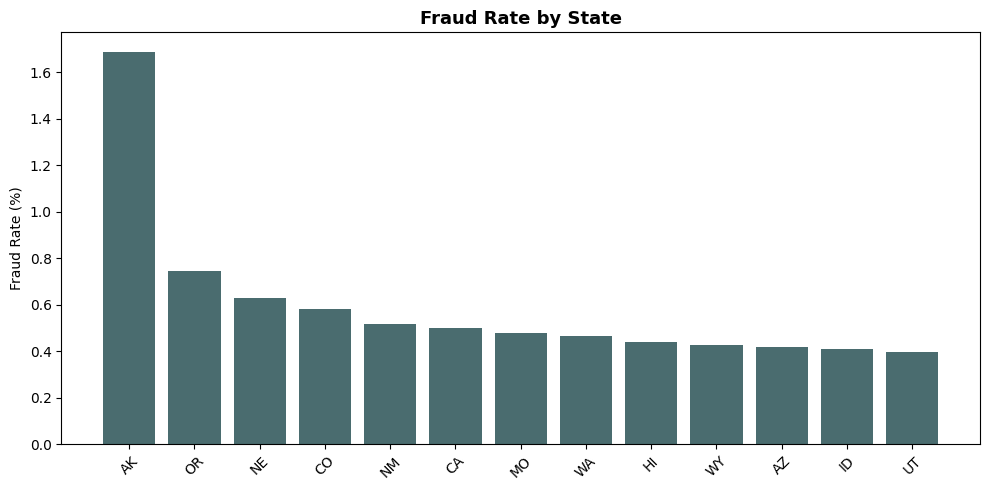

,count,sum,fraud_rate_pct
state,,,
AK,2963,50,1.687
OR,26408,197,0.746
NE,34425,216,0.627
CO,19766,115,0.582
NM,23427,121,0.516
CA,80495,402,0.499
MO,54904,262,0.477
WA,27040,126,0.466
HI,3649,16,0.438


In [65]:
# EDA — fraud rate by state (top 10)
state_fraud = df.groupby('state')['is_fraud'].agg(['count','sum','mean']).sort_values('mean', ascending=False)
state_fraud['fraud_rate_pct'] = state_fraud['mean'] * 100

plt.figure(figsize=(10, 5))
plt.bar(state_fraud.index, state_fraud['fraud_rate_pct'], color='#4A6C6F')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by State', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/04_state_fraud_rate.png', dpi=150, bbox_inches='tight')
plt.show()

state_fraud[['count','sum','fraud_rate_pct']].round(3)

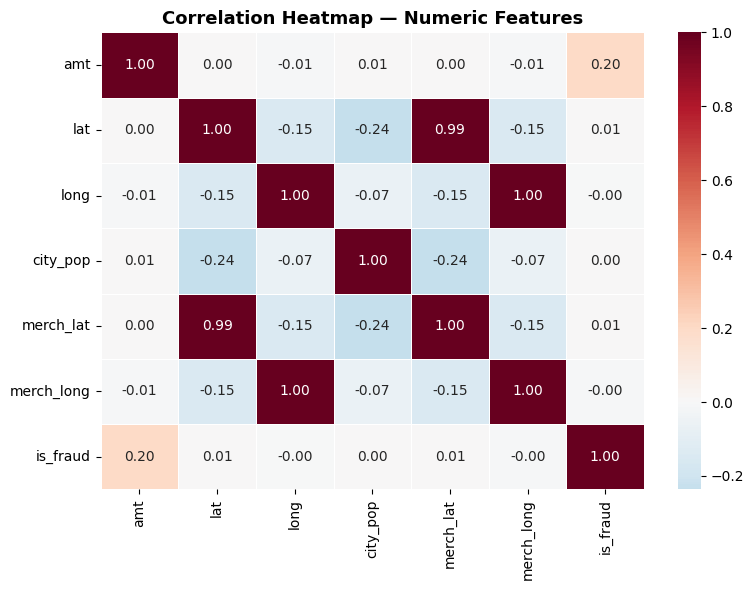

is_fraud      1.000000
amt           0.201023
lat           0.009239
merch_lat     0.008848
city_pop      0.002338
long         -0.004494
merch_long   -0.004550
Name: is_fraud, dtype: float64

In [66]:
# EDA — correlation heatmap (numeric features)
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

corr['is_fraud'].sort_values(ascending=False)

## <span style="color:#B8860B; font-family:Georgia;">🔎 EDA Observations</span>

- **<span style="color:#B03A2E;">Extreme class imbalance</span>**: fraud is only **0.52%** of all transactions (1,782 out of 339,607) — roughly **1 fraud for every 189 legitimate transactions**. This is the single most important fact for modelling: plain accuracy will be a misleading metric, and recall / precision / F1 / ROC-AUC on the fraud class matter far more.
- **<span style="color:#2E8B57;">Amount is a strong signal</span>**: fraudulent transactions average **~$518** vs **~$68** for legitimate ones — roughly **7.6x higher**. The distributions barely overlap at the high end, which is visible in both the log-histogram and the boxplot.
- **<span style="color:#8B5E34;">Category matters</span>**: categories like `shopping_net`, `misc_net`, and `grocery_pos` show noticeably higher fraud rates than categories like `home` or `kids_pets` — online/card-not-present-style categories skew riskier than routine in-person purchases.
- **<span style="color:#4A6C6F;">Geography has mild signal</span>**: fraud rate varies by state, but the effect is much weaker than `amt` or `category` — consistent with fraud being driven mostly by transaction behaviour rather than location alone.
- **<span style="color:#2563EB;">Weak linear correlations</span>**: the correlation heatmap shows no numeric feature is *strongly* linearly correlated with `is_fraud` in isolation (correlations are all small) — this is expected given fraud detection signal here is more about **non-linear interactions** (e.g. category + amount together), which is exactly what a neural network is positioned to pick up on that a single linear feature can't.


In [12]:
df.sample()

,merchant,category,amt,city,state,lat,long,city_pop,job,merch_lat,merch_long,is_fraud
4364,Corwin-Romague,travel,2.26,Ruidoso,NM,33.3305,-105.6933,8874,Licensed conveyancer,32.530481,-105.189792,0


In [13]:
#feature engineering 


X = df.drop(columns = ['is_fraud'])

y = df['is_fraud']

In [14]:
df

,merchant,category,amt,city,state,lat,long,city_pop,job,merch_lat,merch_long,is_fraud
0,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0
1,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,43.150704,-112.154481,0
2,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,41.657520,-122.230347,0
3,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,32.863258,-106.520205,0
4,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",43.753735,-111.454923,0
...,...,...,...,...,...,...,...,...,...,...,...,...
339602,Schmidt-Larkin,home,12.68,Wales,AK,64.7556,-165.6723,145,"Administrator, education",65.623593,-165.186033,0
339603,"Pouros, Walker and Spence",kids_pets,13.02,Greenview,CA,41.5403,-122.9366,308,Call centre manager,41.973127,-123.553032,0
339604,Reilly and Sons,health_fitness,43.77,Luray,MO,40.4931,-91.8912,519,Town planner,39.946837,-91.333331,0
339605,Rau-Robel,kids_pets,86.88,Burbank,WA,46.1966,-118.9017,3684,Musician,46.658340,-119.715054,0


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [18]:
print("Training Set   :", X_train.shape)
print("Validation Set :", X_valid.shape)
print("Testing Set    :", X_test.shape)

print()

print("Training Labels   :", y_train.shape)
print("Validation Labels :", y_valid.shape)
print("Testing Labels    :", y_test.shape)

Training Set   : (237724, 11)
Validation Set : (50941, 11)
Testing Set    : (50942, 11)

Training Labels   : (237724,)
Validation Labels : (50941,)
Testing Labels    : (50942,)


In [21]:
categorical_columns = X_train.select_dtypes(include="object").columns

categorical_columns

numerical_columns = X_train.select_dtypes(include=["number"]).columns

numerical_columns

Index(['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long'], dtype='object')

In [22]:
#encoding categorical column

from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[categorical_columns] = encoder.fit_transform(
    X_train[categorical_columns]
)

X_valid[categorical_columns] = encoder.transform(
    X_valid[categorical_columns]
)

X_test[categorical_columns] = encoder.transform(
    X_test[categorical_columns]
)

In [24]:
#scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_valid = scaler.transform(X_valid)

X_test = scaler.transform(X_test)

In [25]:
X_train[:5]

array([[-0.31612137, -0.06281549, -0.39447962, -0.77309388, -1.15573471,
         0.37120211, -0.93892634, -0.36377417,  1.26960678,  0.19021714,
        -0.97311782],
       [ 1.68559059,  0.7066362 , -0.42338613, -1.59399994, -0.02623784,
        -0.22357082,  1.58517145, -0.05128218, -0.66370925, -0.05804641,
         1.54984605],
       [-0.96680193, -0.06281549,  0.03348528, -0.71152593, -1.15573471,
        -0.63069294, -0.74708093, -0.36535668, -0.92148472, -0.73182112,
        -0.73897867],
       [ 0.5183392 , -0.57578328, -0.19560036, -0.9783204 ,  0.5385106 ,
        -0.73113129,  0.35942584, -0.30326172, -0.27704605, -0.6707647 ,
         0.33432294],
       [-0.92706571,  0.7066362 , -0.38488538, -0.3010729 , -0.8733605 ,
        -0.01977464,  0.64242187, -0.36507142,  0.41035521, -0.19093242,
         0.66923087]])

In [1]:
#convert to tensors 


import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_valid = torch.tensor(X_valid, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_valid = torch.tensor(y_valid.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

NameError: name 'X_train' is not defined

In [28]:
# Create Dataset & DataLoader

from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

In [29]:
#dataloader 

from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,shuffle=True)

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=64,shuffle=False)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

# Design Neural Network Architecture

problem is binary so outout feature will be 2 then lets check no. of input features 


In [34]:
X_train.shape[1]

11

In [36]:
#we have 11 input features 

import torch.nn as nn

# we can use nn.Sequential here but i would like to go with class 

import torch
import torch.nn as nn


class FraudDetectionModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(11, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x


model = FraudDetectionModel()



In [37]:
print(model)

FraudDetectionModel(
  (fc1): Linear(in_features=11, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)


In [40]:
#now creating loss and optimiser

import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [44]:
model.parameters

<bound method Module.parameters of FraudDetectionModel(
  (fc1): Linear(in_features=11, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)>

Take One Batch
      ↓
Forward Pass
      ↓
Calculate Loss
      ↓
Clear Old Gradients
      ↓
Backward Pass
      ↓
Update Weights

In [60]:
#training loop

model.train()
epochs = 10

for epoch in range(epochs):
    epochs_loss = 0
    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epochs_loss = epochs_loss + loss.item()
    avg_loss = epochs_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss}")
        
        
        
        
        
        
    


Epoch [1/10] | Loss: 0.015236023865442117
Epoch [2/10] | Loss: 0.01523594045785944
Epoch [3/10] | Loss: 0.015133138677552794
Epoch [4/10] | Loss: 0.014985416050183099
Epoch [5/10] | Loss: 0.014863197508357054
Epoch [6/10] | Loss: 0.014717080246802535
Epoch [7/10] | Loss: 0.014657098902132447
Epoch [8/10] | Loss: 0.01457565621298037
Epoch [9/10] | Loss: 0.01447801045671702
Epoch [10/10] | Loss: 0.014445634333298995


| Epoch |                 Loss |
| ----: | -------------------: |
|     1 | 0.015236023865442117 |
|     2 | 0.015235940457859440 |
|     3 | 0.015133138677552794 |
|     4 | 0.014985416050183099 |
|     5 | 0.014863197508357054 |
|     6 | 0.014717080246802535 |
|     7 | 0.014657098902132447 |
|     8 | 0.014575656212980370 |
|     9 | 0.014478010456717020 |
|    10 | 0.014445634333298995 |


In [ ]:
#next is model evaluation 


model.eval()



## <span style="color:#B8860B; font-family:Georgia;">📈 Model Evaluation</span>

In [67]:
# run inference on the held-out test set
import numpy as np

all_logits = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        all_logits.append(logits)
        all_labels.append(y_batch)

all_logits = torch.cat(all_logits).squeeze()
all_labels = torch.cat(all_labels).squeeze()

probs = torch.sigmoid(all_logits).numpy()
labels = all_labels.numpy()
preds = (probs >= 0.5).astype(int)

print("Predictions generated for", len(preds), "test samples")

Predictions generated for 50942 test samples


In [68]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_score,
                              recall_score, f1_score, accuracy_score)

acc = accuracy_score(labels, preds)
prec = precision_score(labels, preds, zero_division=0)
rec = recall_score(labels, preds, zero_division=0)
f1 = f1_score(labels, preds, zero_division=0)
auc = roc_auc_score(labels, probs)

print(classification_report(labels, preds, target_names=['Legitimate', 'Fraud'], digits=4))
print(f"ROC-AUC: {auc:.4f}")

              precision    recall  f1-score   support

  Legitimate     0.9965    0.9994    0.9979     50674
       Fraud     0.7333    0.3284    0.4536       268

    accuracy                         0.9958     50942
   macro avg     0.8649    0.6639    0.7258     50942
weighted avg     0.9951    0.9958    0.9950     50942

ROC-AUC: 0.9069


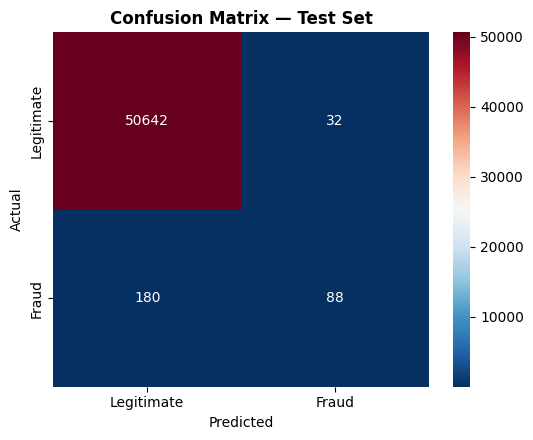

In [69]:
# confusion matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdBu_r',
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix — Test Set', fontsize=12, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../images/06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

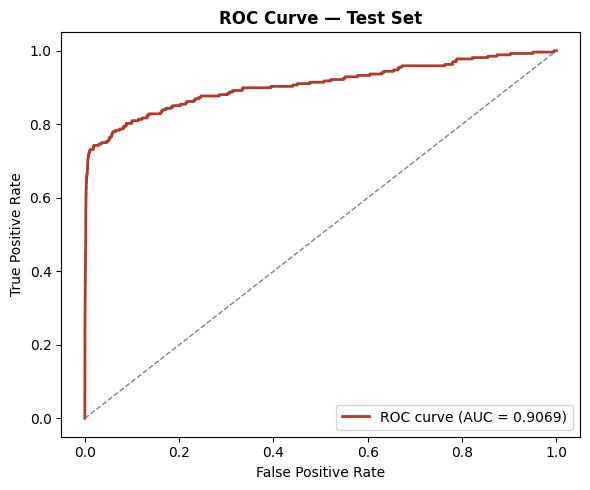

In [70]:
# ROC curve
fpr, tpr, _ = roc_curve(labels, probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#B03A2E', linewidth=2, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../images/07_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## <span style="color:#B8860B; font-family:Georgia;">✅ Results</span>

**<span style="color:#2563EB;">Test set:</span>** 50,942 transactions (268 fraud, 50,674 legitimate)

| Metric | Legitimate | Fraud |
|---|---|---|
| Precision | **<span style="color:#2E8B57;">99.65%</span>** | **<span style="color:#B03A2E;">73.33%</span>** |
| Recall | **<span style="color:#2E8B57;">99.94%</span>** | **<span style="color:#B03A2E;">32.84%</span>** |
| F1-score | **<span style="color:#2E8B57;">99.79%</span>** | **<span style="color:#B03A2E;">45.36%</span>** |

**<span style="color:#8B5E34;">Overall accuracy:</span> 99.58%** &nbsp;|&nbsp; **<span style="color:#8B5E34;">ROC-AUC:</span> 0.907**

- **<span style="color:#2563EB;">Accuracy is not the right headline metric here</span>** — with fraud at only 0.52% of transactions, a model that predicts "legitimate" for everything would already score ~99.47% accuracy while catching zero fraud. The metrics that actually matter are **fraud recall (32.8%)**, **fraud precision (73.3%)**, and **ROC-AUC (0.91)**.
- **<span style="color:#B03A2E;">Recall is the main bottleneck</span>**: at the default 0.5 threshold the model only catches about **1 in 3 fraud cases** in the test set. This is expected — the network was trained with a plain `BCEWithLogitsLoss` (no `pos_weight`) on data that's ~189:1 imbalanced, so the loss is dominated by the majority class and the model stays conservative about flagging fraud.
- **<span style="color:#2E8B57;">ROC-AUC of 0.91 shows the model has genuinely learned useful separation</span>** between fraud and legitimate transactions — the ranking of risk is good, it's the fixed 0.5 decision threshold that's costing recall. **When it does flag fraud, it's right ~73% of the time** — precision is solid.
- **<span style="color:#8B5E34;">A lower decision threshold would trade precision for recall</span>** — worth exploring (e.g. 0.15–0.3) if the goal is to catch more fraud at the cost of more false alarms, which is usually the right trade-off in real fraud detection (a missed fraud is far costlier than a manual review of a false positive). The Streamlit app exposes this threshold as an adjustable slider.


## <span style="color:#B8860B; font-family:Georgia;">💾 Saving Artifacts for Deployment</span>

In [71]:
import joblib, json, os

os.makedirs('../models', exist_ok=True)

# model weights
torch.save(model.state_dict(), '../models/fraud_model.pth')

# preprocessing artifacts
joblib.dump(encoder, '../models/encoder.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(categorical_columns), '../models/categorical_columns.pkl')
joblib.dump(list(numerical_columns), '../models/numerical_columns.pkl')
joblib.dump(list(X.columns), '../models/feature_order.pkl')

# metrics
metrics = {
    "accuracy": float(acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1_score": float(f1),
    "roc_auc": float(auc),
    "test_size": int(len(labels)),
    "fraud_in_test": int(labels.sum()),
    "threshold": 0.5
}
with open('../models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Saved: fraud_model.pth, encoder.pkl, scaler.pkl, categorical_columns.pkl,")
print("       numerical_columns.pkl, feature_order.pkl, metrics.json")
print()
print(json.dumps(metrics, indent=2))

Saved: fraud_model.pth, encoder.pkl, scaler.pkl, categorical_columns.pkl,
       numerical_columns.pkl, feature_order.pkl, metrics.json

{
  "accuracy": 0.9958384044599741,
  "precision": 0.7333333333333333,
  "recall": 0.3283582089552239,
  "f1_score": 0.4536082474226804,
  "roc_auc": 0.9068862553672024,
  "test_size": 50942,
  "fraud_in_test": 268,
  "threshold": 0.5
}


## <span style="color:#B8860B; font-family:Georgia;">🏁 Conclusion & Next Steps</span>

This notebook trained a compact PyTorch ANN (`11 → 16 → 8 → 1`) to flag fraudulent
credit-card transactions from merchant, amount, location, and cardholder features.
On the held-out test set it reaches **99.58% accuracy**, **0.907 ROC-AUC**, and catches
**~33% of fraud** at **~73% precision** using the default 0.5 threshold.

**<span style="color:#2563EB;">Possible improvements (not applied here, to keep this notebook's original training run intact):</span>**
- Add `pos_weight` to `BCEWithLogitsLoss` (or oversample/undersample) to directly counter the 189:1 class imbalance and lift recall
- Tune the decision threshold on the validation set instead of using a fixed 0.5 cutoff — the app lets you experiment with this live
- Try a deeper network, more epochs, or a learning-rate schedule
- Compare against a gradient-boosted tree baseline (XGBoost/LightGBM), which often handles tabular imbalance well out of the box
- k-fold cross-validation for a more robust performance estimate

The trained model, encoder, scaler, and column order are saved to `../models/` and
are consumed directly by the Streamlit app in `../app/app.py`.
